# 04b: Matchup Building

**Prerequisite:** Run `04a_feature_building.ipynb` first (creates `processed/team_features.csv`)

**Goal:** Build matchup differential features for ML training.

### Approach (Cross-Season, No Leakage)

| Source | Features From | Games From | Leakage? |
|--------|--------------|------------|----------|
| Regular season | Season S-1 stats | Season S games | None |
| Tournament | Season S stats | Season S tourney | None |

```
TRAINING:
  2003 stats -> predict 2004 regular games
  2004 stats -> predict 2005 regular games
  ...all combined into one training set...
  + tournament games (same-season, no leakage)

VALIDATION:
  2024 stats -> predict 2025 games

PREDICTION:
  2025 stats -> predict 2026 tournament
```

**Output:** `processed/matchup_features.csv` and `processed/tourney_matchup_features.csv`

## Setup

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import (
    load_regular_season_results, load_tourney_results,
    load_teams, PROCESSED_DIR
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)

YEAR_START = 2003

teams = load_teams('M')
team_lookup = dict(zip(teams['TeamID'], teams['TeamName']))

## 1. Load Team Features (from 04a)

In [13]:
team_features = pd.read_csv(PROCESSED_DIR / 'team_features.csv')
print(f"Team features loaded: {team_features.shape}")
print(f"Seasons: {team_features['Season'].min()} to {team_features['Season'].max()}")
print(f"Columns: {team_features.columns.tolist()}")

Team features loaded: (8346, 23)
Seasons: 2003 to 2026
Columns: ['Season', 'TeamID', 'Games', 'Wins', 'Losses', 'WinPct', 'AvgPointsFor', 'AvgPointsAgainst', 'AvgMargin', 'eFG_Off', 'TORate_Off', 'ORBRate_Off', 'FTRate_Off', 'Elo_RegSeason', 'POM_Rank', 'SAG_Rank', 'Composite_Rank', 'SeedNum', 'IsSeeded', 'ConfStrength_Rank', 'Last15WinPct', 'Last15AvgMargin', 'ConfTourneyChamp']


## 2. Load Game Data

In [14]:
regular = load_regular_season_results('M')
regular = regular[regular['Season'] >= YEAR_START]
print(f"Regular season games: {len(regular):,}")

tourney = load_tourney_results('M')
tourney = tourney[tourney['Season'] >= YEAR_START]
print(f"Tournament games: {len(tourney):,}")

Regular season games: 122,775
Tournament games: 1,449


## 3. Build Matchup Helper

In [15]:
def build_matchup_row(season, wteam, lteam, features_df, feature_season, diff_cols, game_type):
    """Build one matchup row using features from feature_season."""
    team1 = min(wteam, lteam)
    team2 = max(wteam, lteam)
    target = 1 if wteam == team1 else 0
    
    t1 = features_df[(features_df['Season'] == feature_season) & (features_df['TeamID'] == team1)]
    t2 = features_df[(features_df['Season'] == feature_season) & (features_df['TeamID'] == team2)]
    
    if len(t1) == 0 or len(t2) == 0:
        return None
    
    t1, t2 = t1.iloc[0], t2.iloc[0]
    row = {'Season': season, 'Team1': team1, 'Team2': team2,
           'Target': target, 'GameType': game_type}
    
    for col in diff_cols:
        val1, val2 = t1.get(col, np.nan), t2.get(col, np.nan)
        row[f'{col}_Diff'] = val1 - val2 if pd.notna(val1) and pd.notna(val2) else np.nan
    
    return row

print("Helper function ready.")

Helper function ready.


## 4. Build Regular Season Matchups (Cross-Season)

Use **previous year's stats** to predict this year's games. Zero leakage.

In [16]:
# Features for regular season — includes all team-level features
reg_diff_features = ['WinPct', 'AvgPointsFor', 'AvgPointsAgainst', 'AvgMargin',
                     'eFG_Off', 'TORate_Off', 'ORBRate_Off', 'FTRate_Off',
                     'Elo_RegSeason', 'POM_Rank', 'SAG_Rank', 'Composite_Rank',
                     'SeedNum', 'IsSeeded',
                     'ConfStrength_Rank', 'Last15WinPct', 'Last15AvgMargin', 'ConfTourneyChamp']

print("Building regular season matchups (cross-season)...")
print("This processes ~120K games, may take a few minutes.\n")

reg_matchup_rows = []
skipped = 0

for _, game in regular.iterrows():
    season = game['Season']
    prev_season = season - 1
    
    # Skip first year (no previous season stats)
    if prev_season < YEAR_START:
        skipped += 1
        continue
    
    row = build_matchup_row(season, game['WTeamID'], game['LTeamID'],
                           team_features, prev_season, reg_diff_features, 'Regular')
    if row:
        reg_matchup_rows.append(row)
    else:
        skipped += 1

reg_matchups = pd.DataFrame(reg_matchup_rows)
print(f"Regular season matchups: {len(reg_matchups):,}")
print(f"Skipped (no prev season data): {skipped:,}")
print(f"Seasons: {reg_matchups['Season'].min()} to {reg_matchups['Season'].max()}")
print(f"Target: {reg_matchups['Target'].value_counts().to_dict()}")

Building regular season matchups (cross-season)...
This processes ~120K games, may take a few minutes.

Regular season matchups: 116,862
Skipped (no prev season data): 5,913
Seasons: 2004 to 2026
Target: {0: 59997, 1: 56865}


## 5. Build Tournament Matchups (Same-Season)

Use **current season's stats** to predict tournament. No leakage because regular season is complete before tournament.

In [17]:
# Tournament uses same features as regular season
tourney_diff_features = reg_diff_features

print("Building tournament matchups (same-season)...\n")

tourney_matchup_rows = []
for _, game in tourney.iterrows():
    row = build_matchup_row(game['Season'], game['WTeamID'], game['LTeamID'],
                           team_features, game['Season'], tourney_diff_features, 'Tournament')
    if row:
        tourney_matchup_rows.append(row)

tourney_matchups = pd.DataFrame(tourney_matchup_rows)
print(f"Tournament matchups: {len(tourney_matchups):,}")
print(f"Seasons: {tourney_matchups['Season'].min()} to {tourney_matchups['Season'].max()}")
print(f"Target: {tourney_matchups['Target'].value_counts().to_dict()}")

Building tournament matchups (same-season)...

Tournament matchups: 1,449
Seasons: 2003 to 2025
Target: {1: 725, 0: 724}


## 6. Combine & Summary

In [18]:
matchups = pd.concat([reg_matchups, tourney_matchups], ignore_index=True)

print(f"{'='*60}")
print(f"COMBINED MATCHUP DATASET")
print(f"{'='*60}")
print(f"Total matchups: {len(matchups):,}")
print(f"  Regular season (cross-season): {len(reg_matchups):,}")
print(f"  Tournament (same-season):      {len(tourney_matchups):,}")
print(f"\nTarget distribution: {matchups['Target'].value_counts().to_dict()}")
print(f"\nFeature completeness:")
for col in [c for c in matchups.columns if c.endswith('_Diff')]:
    pct = 100 * matchups[col].notna().sum() / len(matchups)
    print(f"  {col}: {pct:.0f}%")

matchups.head()

COMBINED MATCHUP DATASET
Total matchups: 118,311
  Regular season (cross-season): 116,862
  Tournament (same-season):      1,449

Target distribution: {0: 60721, 1: 57590}

Feature completeness:
  WinPct_Diff: 100%
  AvgPointsFor_Diff: 100%
  AvgPointsAgainst_Diff: 100%
  AvgMargin_Diff: 100%
  eFG_Off_Diff: 100%
  TORate_Off_Diff: 100%
  ORBRate_Off_Diff: 100%
  FTRate_Off_Diff: 100%
  Elo_RegSeason_Diff: 100%
  POM_Rank_Diff: 100%
  SAG_Rank_Diff: 92%
  Composite_Rank_Diff: 100%
  SeedNum_Diff: 100%
  IsSeeded_Diff: 100%
  ConfStrength_Rank_Diff: 100%
  Last15WinPct_Diff: 100%
  Last15AvgMargin_Diff: 100%
  ConfTourneyChamp_Diff: 100%


,Season,Team1,Team2,Target,GameType,WinPct_Diff,AvgPointsFor_Diff,AvgPointsAgainst_Diff,AvgMargin_Diff,eFG_Off_Diff,TORate_Off_Diff,ORBRate_Off_Diff,FTRate_Off_Diff,Elo_RegSeason_Diff,POM_Rank_Diff,SAG_Rank_Diff,Composite_Rank_Diff,SeedNum_Diff,IsSeeded_Diff,ConfStrength_Rank_Diff,Last15WinPct_Diff,Last15AvgMargin_Diff,ConfTourneyChamp_Diff
0,2004,1266,1385,1,Regular,0.269704,7.013547,-1.873153,8.886700,0.061014,0.022128,-0.017106,0.068003,101.968299,-65.0,-51.0,-61.145221,-97.0,1.0,2.0,0.400000,11.666667,0.0
1,2004,1272,1448,0,Regular,-0.034483,-3.896552,-1.793103,-2.103448,0.007360,-0.010621,-0.062543,-0.060698,-5.475874,8.0,15.0,10.500000,5.0,0.0,5.0,0.066667,5.866667,0.0
2,2004,1104,1338,0,Regular,-0.259524,-5.314286,6.166667,-11.480952,-0.054943,-0.020561,0.045814,-0.008273,-146.484227,31.0,34.0,34.590074,8.0,0.0,-5.0,-0.400000,-11.533333,-1.0
3,2004,1211,1386,0,Regular,-0.051168,6.443826,8.917686,-2.473860,0.026089,0.010916,0.016792,0.077116,-11.758595,23.0,19.0,18.593750,2.0,0.0,1.0,0.066667,-1.066667,0.0
4,2004,1227,1414,1,Regular,0.045567,6.233990,3.431034,2.802956,0.021941,-0.041556,0.029108,-0.076631,23.197828,-44.0,-56.0,-43.937500,0.0,0.0,-5.0,0.066667,3.400000,0.0


---
## 7. Visualize: Which Features Predict Winners?

Green = Team1 won, Red = Team1 lost. **More separation = more predictive.**

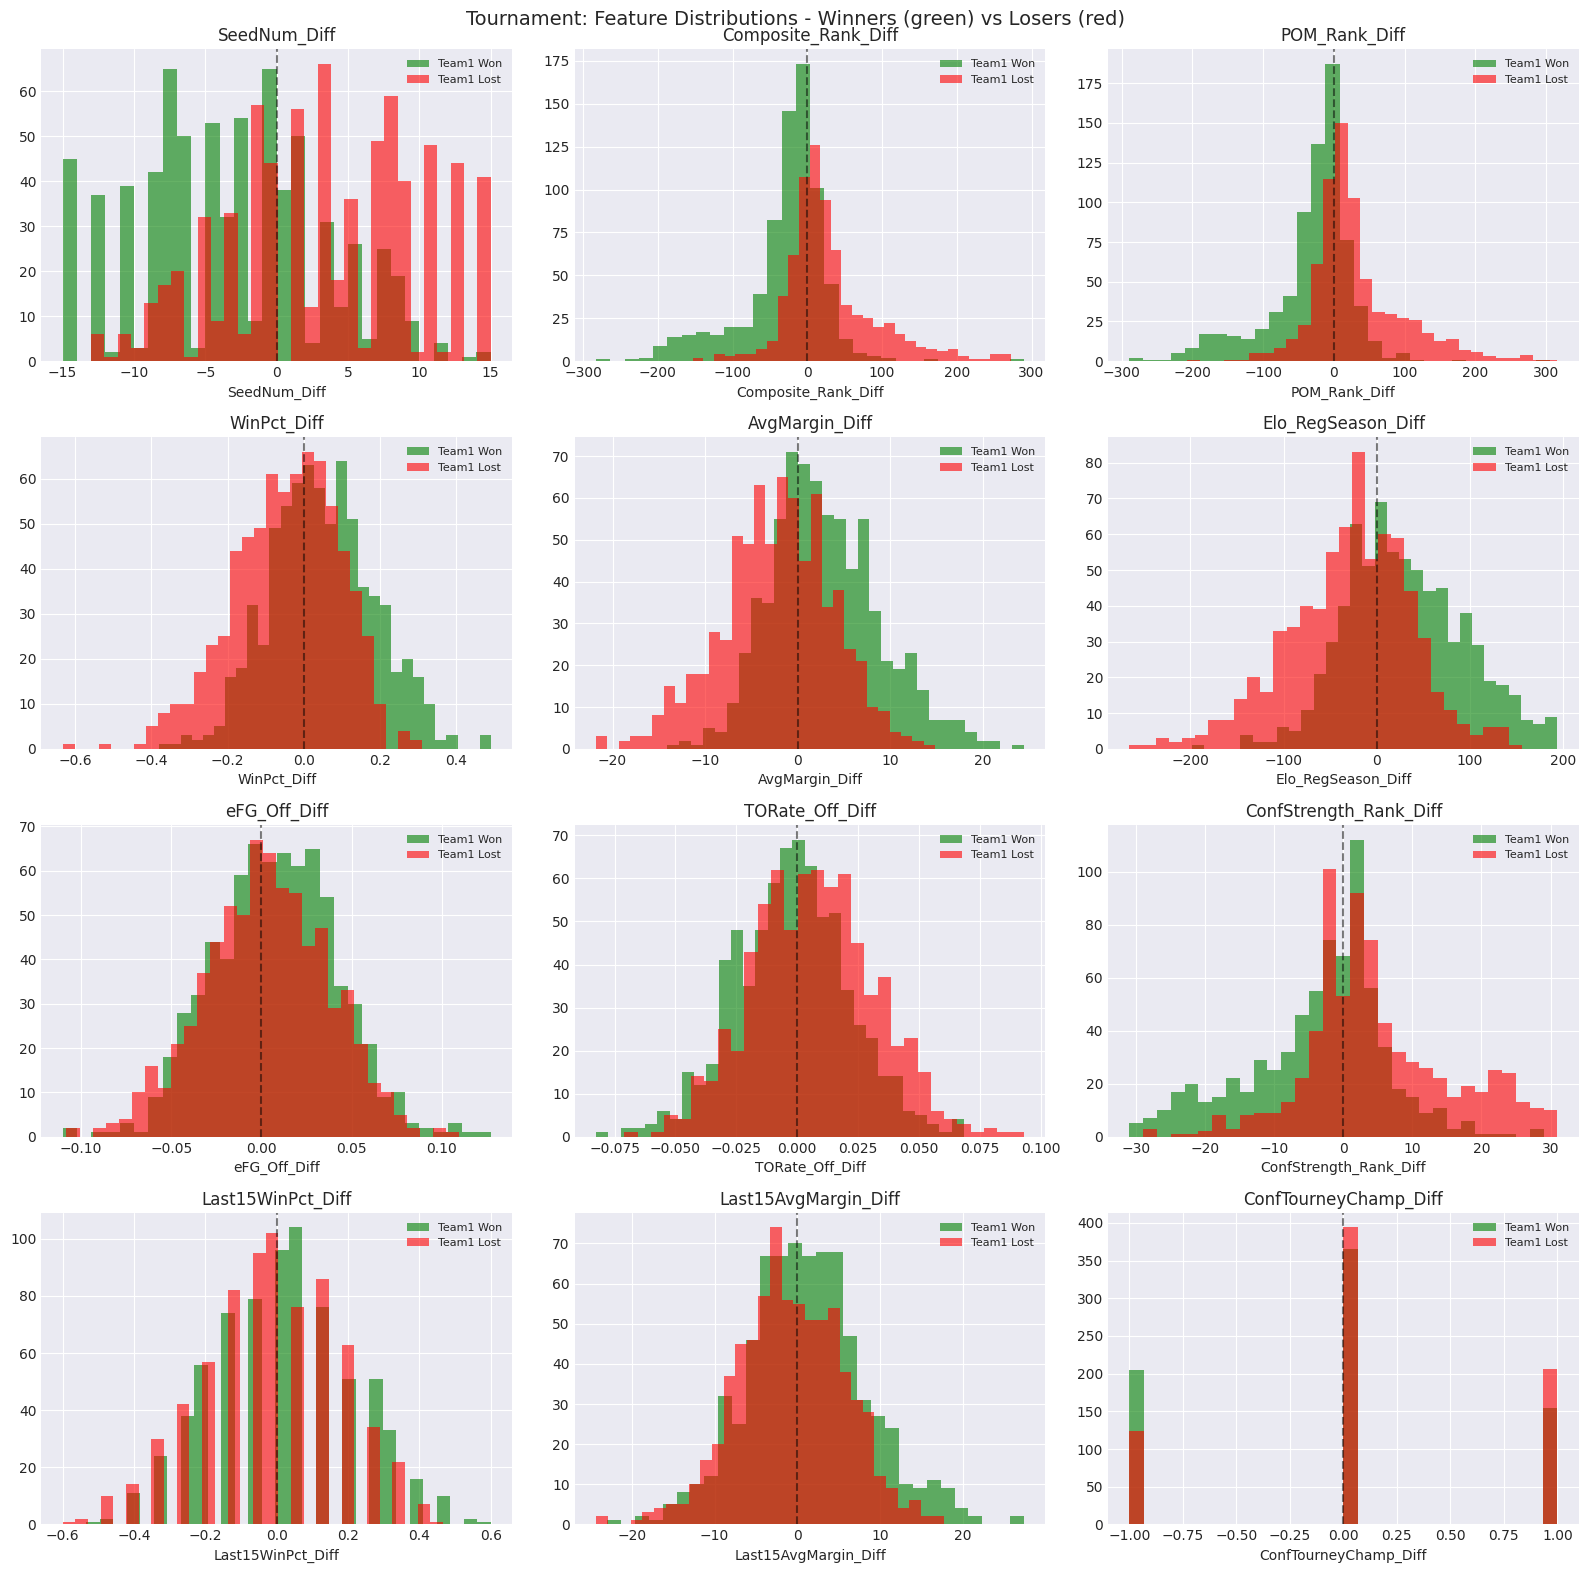

In [19]:
# Use tournament matchups for visualization (cleaner signal)
viz_data = tourney_matchups.copy()

plot_features = ['SeedNum_Diff', 'Composite_Rank_Diff', 'POM_Rank_Diff',
                 'WinPct_Diff', 'AvgMargin_Diff', 'Elo_RegSeason_Diff',
                 'eFG_Off_Diff', 'TORate_Off_Diff', 'ConfStrength_Rank_Diff',
                 'Last15WinPct_Diff', 'Last15AvgMargin_Diff', 'ConfTourneyChamp_Diff']

available = [c for c in plot_features if c in viz_data.columns]
n_cols = 3
n_rows = (len(available) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(available):
    data = viz_data.dropna(subset=[col])
    axes[i].hist(data[data['Target'] == 1][col], bins=30, alpha=0.6, label='Team1 Won', color='green')
    axes[i].hist(data[data['Target'] == 0][col], bins=30, alpha=0.6, label='Team1 Lost', color='red')
    axes[i].axvline(0, color='black', linestyle='--', alpha=0.5)
    axes[i].set_xlabel(col)
    axes[i].legend(fontsize=8)
    axes[i].set_title(col)

for j in range(len(available), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tournament: Feature Distributions - Winners (green) vs Losers (red)', fontsize=14)
plt.tight_layout()
plt.show()

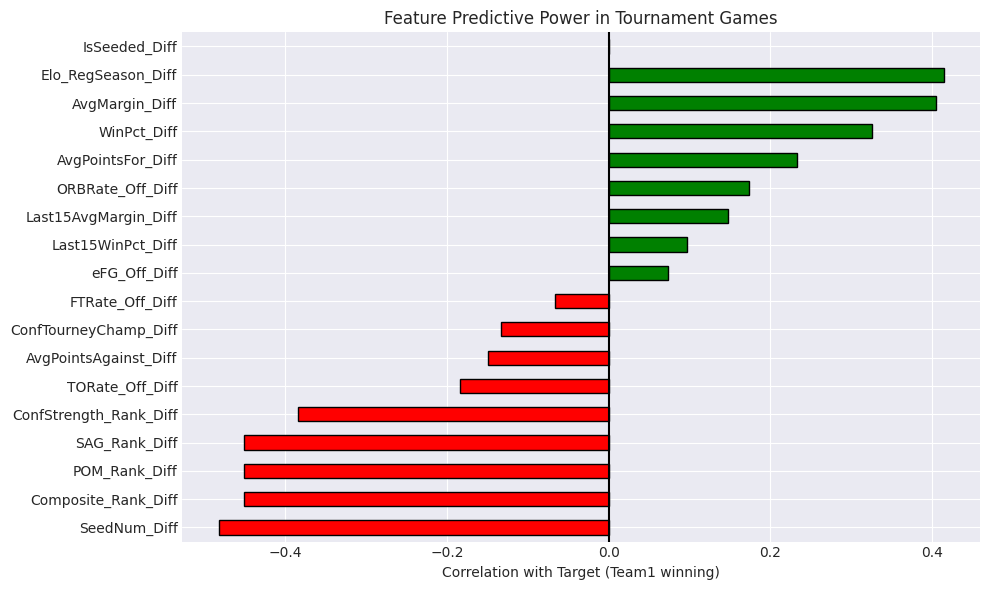

Longer bars = more predictive.
Green = positive diff means Team1 more likely to win.
Red = negative diff means Team1 more likely to win (rank columns are inverted).


In [20]:
# Feature predictive power: correlation with target
diff_cols = [c for c in tourney_matchups.columns if c.endswith('_Diff')]
target_corr = tourney_matchups[diff_cols + ['Target']].corr()['Target'].drop('Target').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if v > 0 else 'red' for v in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_xlabel('Correlation with Target (Team1 winning)')
ax.set_title('Feature Predictive Power in Tournament Games')
ax.axvline(0, color='black', linestyle='-')
plt.tight_layout()
plt.show()

print("Longer bars = more predictive.")
print("Green = positive diff means Team1 more likely to win.")
print("Red = negative diff means Team1 more likely to win (rank columns are inverted).")

## 8. Feature Correlations

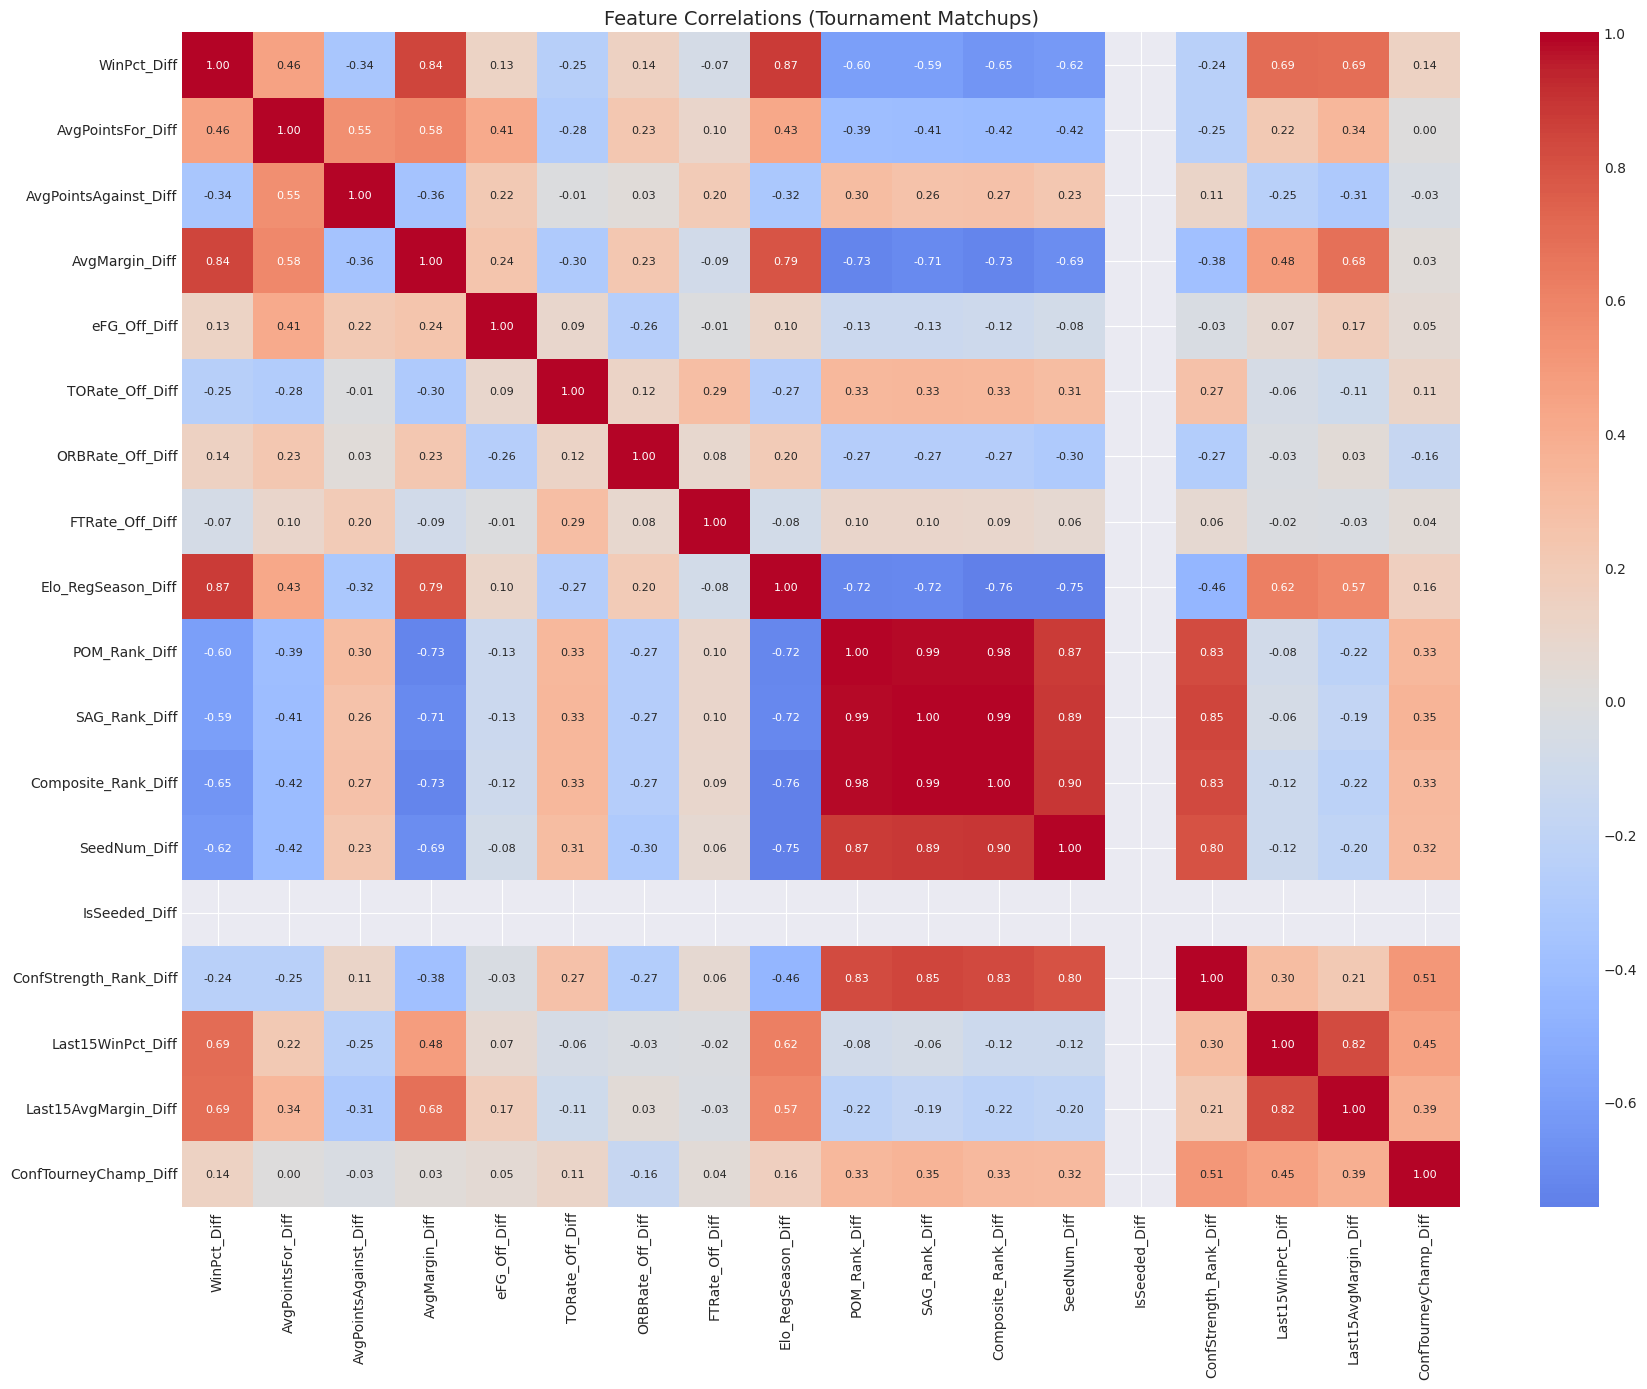

Highly correlated pairs (|r| > 0.7):
  WinPct_Diff <-> AvgMargin_Diff: 0.84
  WinPct_Diff <-> Elo_RegSeason_Diff: 0.87
  AvgMargin_Diff <-> Elo_RegSeason_Diff: 0.79
  AvgMargin_Diff <-> POM_Rank_Diff: -0.73
  AvgMargin_Diff <-> SAG_Rank_Diff: -0.71
  AvgMargin_Diff <-> Composite_Rank_Diff: -0.73
  Elo_RegSeason_Diff <-> POM_Rank_Diff: -0.72
  Elo_RegSeason_Diff <-> SAG_Rank_Diff: -0.72
  Elo_RegSeason_Diff <-> Composite_Rank_Diff: -0.76
  Elo_RegSeason_Diff <-> SeedNum_Diff: -0.75
  POM_Rank_Diff <-> SAG_Rank_Diff: 0.99
  POM_Rank_Diff <-> Composite_Rank_Diff: 0.98
  POM_Rank_Diff <-> SeedNum_Diff: 0.87
  POM_Rank_Diff <-> ConfStrength_Rank_Diff: 0.83
  SAG_Rank_Diff <-> Composite_Rank_Diff: 0.99
  SAG_Rank_Diff <-> SeedNum_Diff: 0.89
  SAG_Rank_Diff <-> ConfStrength_Rank_Diff: 0.85
  Composite_Rank_Diff <-> SeedNum_Diff: 0.90
  Composite_Rank_Diff <-> ConfStrength_Rank_Diff: 0.83
  SeedNum_Diff <-> ConfStrength_Rank_Diff: 0.80
  Last15WinPct_Diff <-> Last15AvgMargin_Diff: 0.82


In [21]:
diff_cols = [c for c in tourney_matchups.columns if c.endswith('_Diff')]
corr_data = tourney_matchups.dropna(subset=diff_cols)

fig, ax = plt.subplots(figsize=(18, 14))
corr = corr_data[diff_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature Correlations (Tournament Matchups)', fontsize=14)
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
print("Highly correlated pairs (|r| > 0.7):")
for i in range(len(diff_cols)):
    for j in range(i+1, len(diff_cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {diff_cols[i]} <-> {diff_cols[j]}: {r:.2f}")

---
## 9. Save Everything

In [22]:
# Save combined matchup features
matchups.to_csv(PROCESSED_DIR / 'matchup_features.csv', index=False)
print(f"Saved: processed/matchup_features.csv ({matchups.shape})")

# Save tournament-only matchups separately
tourney_matchups.to_csv(PROCESSED_DIR / 'tourney_matchup_features.csv', index=False)
print(f"Saved: processed/tourney_matchup_features.csv ({tourney_matchups.shape})")

print(f"\n{'='*60}")
print(f"FINAL SUMMARY")
print(f"{'='*60}")
print(f"\nTraining data:")
print(f"  Regular season matchups (cross-season): {len(reg_matchups):,}")
print(f"  Tournament matchups (same-season):      {len(tourney_matchups):,}")
print(f"  Total:                                   {len(matchups):,}")
print(f"\nMatchup features (differentials):")
feature_list = [
    ('WinPct_Diff', 'Win % difference'),
    ('AvgPointsFor_Diff', 'Offensive output difference'),
    ('AvgPointsAgainst_Diff', 'Defensive quality difference'),
    ('AvgMargin_Diff', 'Dominance level difference'),
    ('eFG_Off_Diff', 'Shooting efficiency difference'),
    ('TORate_Off_Diff', 'Turnover rate difference'),
    ('ORBRate_Off_Diff', 'Offensive rebound difference'),
    ('FTRate_Off_Diff', 'Free throw rate difference'),
    ('Elo_RegSeason_Diff', 'Elo strength difference'),
    ('POM_Rank_Diff', 'Pomeroy ranking difference'),
    ('SAG_Rank_Diff', 'Sagarin ranking difference'),
    ('Composite_Rank_Diff', 'Composite ranking difference'),
    ('SeedNum_Diff', 'Tournament seed difference (1-16, 100=unseeded)'),
    ('IsSeeded_Diff', 'Seeded status difference'),
    ('ConfStrength_Rank_Diff', 'Conference strength difference'),
    ('Last15WinPct_Diff', 'Last 15 games win % difference'),
    ('Last15AvgMargin_Diff', 'Last 15 games avg margin difference'),
    ('ConfTourneyChamp_Diff', 'Conf tourney champ difference'),
]
for i, (col, desc) in enumerate(feature_list, 1):
    print(f"  {i:2d}. {col:<30s} -> {desc}")

print(f"\nNext: 05_modeling.ipynb -> Train on 2003-2024, validate on 2025, predict 2026")

Saved: processed/matchup_features.csv ((118311, 23))
Saved: processed/tourney_matchup_features.csv ((1449, 23))

FINAL SUMMARY

Training data:
  Regular season matchups (cross-season): 116,862
  Tournament matchups (same-season):      1,449
  Total:                                   118,311

Matchup features (differentials):
   1. WinPct_Diff                    -> Win % difference
   2. AvgPointsFor_Diff              -> Offensive output difference
   3. AvgPointsAgainst_Diff          -> Defensive quality difference
   4. AvgMargin_Diff                 -> Dominance level difference
   5. eFG_Off_Diff                   -> Shooting efficiency difference
   6. TORate_Off_Diff                -> Turnover rate difference
   7. ORBRate_Off_Diff               -> Offensive rebound difference
   8. FTRate_Off_Diff                -> Free throw rate difference
   9. Elo_RegSeason_Diff             -> Elo strength difference
  10. POM_Rank_Diff                  -> Pomeroy ranking difference
  11. SAG